# Phase 2 &mdash; XGBoost on the UCI *Default of Credit Card Clients* dataset

Continues the section numbering of `data_mining_assignment.ipynb`, which carried Phase 1
(&sect;1&ndash;&sect;5: audit, cleaning, univariate and multivariate exploration).

**This notebook computes nothing.** Every number and figure below is read from
`results/*.json` and `figures/*.png`, written by the fourteen scripts in `experiments/`.
That separation is deliberate:

- fourteen experiments in one kernel is neither restartable nor cacheable, and a
  half-executed notebook silently mixes numbers from two different runs;
- the report quotes `results/manifest.csv`, so a figure and a table cannot disagree
  because one of them was retyped;
- this notebook executes in seconds, so it can be re-run for presentation at any time.

To regenerate the underlying results from a clean checkout, see `SETUP.md`.

**Research questions**, carried verbatim from the Phase 1 proposal:

1. Does the marginal performance gain achieved by ensemble architectures and non-linear
   models justify the corresponding loss in direct rule-based interpretability?
2. Can post-hoc explainability techniques bridge this gap by providing
   regulatory-compliant decision auditability for non-linear ensemble models?

&sect;7 answers the first. &sect;12 answers the second.

In [1]:
from IPython.display import Image, Markdown, display
import pandas as pd

from src import report
from src.config import FIGDIR, LGD, NIM, N_FOLDS, N_REPEATS, R_HEADLINE, SEED, TEST_SIZE

pd.set_option("display.max_columns", 40, "display.width", 200,
              "display.max_colwidth", 60)

def fig(name, width=900):
    return display(Image(filename=str(FIGDIR / f"{name}.png"), width=width))

def notes(exp_id):
    return display(Markdown(f"> {report.notes(exp_id)}"))

def show(df, caption=None):
    if caption:
        display(Markdown(f"**{caption}**"))
    return display(df.style.hide(axis="index"))

---
## &sect;6 Modelling setup

The evaluation architecture is fixed before any model is fitted, because almost every
fatal flaw available in this assignment is a protocol flaw rather than a modelling one.

**De-duplication precedes splitting.** Phase 1's cleaning already removed duplicate
feature-rows. Had it not, identical clients straddling the train/test boundary would
inflate every score reported here.

**Hold-out.** 80/20 stratified on `DEFAULT`, `random_state=SEED`. Touched exactly once,
by `exp14_final.py`.

**Two cross-validation structures, for two different jobs.** `StratifiedKFold(5,
shuffle=True, random_state=42)` selects models; `RepeatedStratifiedKFold(5, 5,
random_state=7)` reports variance by refitting the *already selected* configuration 25
times. Using repeated CV inside the tuner would multiply runtime by five and buy nothing,
since selection only needs a ranking.

**Early stopping without contamination.** XGBoost needs a validation set to stop on. That
set is carved as an inner stratified 15% slice of *each fold's training half*, so the
outer validation fold is never seen by the stopping rule and the test set never at all
(`src/runner.py::fit_one`).

**Threshold freezing.** Out-of-fold probabilities are produced on the training portion,
the cost-minimising threshold is chosen on those, and the resulting scalar is frozen and
applied unchanged to the test set (`src/costs.py::pick_threshold_oof`). Sweeping a
threshold against test labels is the single most common fatal flaw in this task.

In [2]:
from src.data import clean, engineer, load_raw, load_splits, RAW_FEATURES, ENGINEERED

df = clean(load_raw())
s = load_splits()
y = df["DEFAULT"].to_numpy()

setup = pd.DataFrame([
    ("Cleaned rows", f"{len(df):,}"),
    ("Defaults", f"{int(y.sum()):,} ({y.mean():.2%})"),
    ("Raw predictors", f"{len(RAW_FEATURES)}"),
    ("Engineered predictors (§10.2)", f"{len(ENGINEERED)}"),
    ("Train / test rows", f"{len(s['train_idx']):,} / {len(s['test_idx']):,}"),
    ("Test positives", f"{int(y[s['test_idx']].sum()):,}"),
    ("Train default rate", f"{y[s['train_idx']].mean():.4%}"),
    ("Test default rate", f"{y[s['test_idx']].mean():.4%}"),
    ("Train/test index overlap", f"{len(set(s['train_idx']) & set(s['test_idx']))}"),
    ("Selection folds", f"{N_FOLDS}"),
    ("Variance-reporting fits", f"{N_FOLDS * N_REPEATS}"),
    ("scale_pos_weight (neg/pos)", f"{(len(y) - y.sum()) / y.sum():.4f}"),
    ("Cost ratio r = LGD/NIM", f"{LGD}/{NIM} = {LGD / NIM:.2f}, reported as {R_HEADLINE}:1"),
    ("Seed", f"{SEED}"),
], columns=["Quantity", "Value"])
show(setup, "Table 6.1 — modelling setup, recomputed from the cached splits")

**Table 6.1 — modelling setup, recomputed from the cached splits**

Quantity,Value
Cleaned rows,"29,944"
Defaults,"6,622 (22.11%)"
Raw predictors,23
Engineered predictors (§10.2),17
Train / test rows,"23,955 / 5,989"
Test positives,"1,324"
Train default rate,22.1165%
Test default rate,22.1072%
Train/test index overlap,0
Selection folds,5


---
## &sect;7 Complexity ladder &mdash; research question 1

A single XGBoost number cannot answer whether ensemble complexity is *justified*, because
justification is a comparison. The ladder makes it one: six rungs of increasing capability,
each priced in interpretability.

The `Cost to read` column is the number of parameters or tree nodes a human must read to
reproduce a single decision. It converts the accuracy/explainability trade-off from an
assertion into a measured axis.

> **Rungs 2 and 3 are untuned internal reference implementations.** They locate XGBoost on
> a capability axis. They are **not** the group's Logistic Regression or Decision Tree
> submissions, which Declan and Izak tune separately and which will score higher than the
> rungs below.

**Table 1 — the complexity ladder (25 repeated-CV fits, mean ± SD)**

Model,Features,ROC-AUC,PR-AUC,Brier,Accuracy @0.5,Recall @0.5,Interpretability,Cost to read
Majority class,23,0.5000 +/- 0.0000,0.2212 +/- 0.0001,0.2212 +/- 0.0001,0.7788,0.0000,total (1 constant),1
"PAY_0 only, depth-1 tree",1,0.6441 +/- 0.0075,0.3774 +/- 0.0107,0.1460 +/- 0.0021,0.8197,0.3292,single rule,1
PAY_0 as an ordinal score (no model fitted),1,0.6910 +/- 0.0083,0.4394 +/- 0.0114,--,--,--,rank on one column,1
Logistic regression (defaults),23,0.7248 +/- 0.0086,0.5034 +/- 0.0131,0.1448 +/- 0.0016,0.8094,0.2374,23 coefficients + intercept,24
Decision tree (depth-tuned),23,0.7542 +/- 0.0103,0.5062 +/- 0.0137,0.1383 +/- 0.0025,0.8195,0.3522,rule set,109
Random forest (defaults),23,0.7641 +/- 0.0096,0.5374 +/- 0.0148,0.1384 +/- 0.0026,0.8183,0.3769,not directly available - see SHAP,692674
XGBoost (library defaults),23,0.7619 +/- 0.0080,0.5293 +/- 0.0113,0.1415 +/- 0.0026,0.8185,0.3701,not directly available - see SHAP,100
XGBoost (tuned),23,0.7845 +/- 0.0071,0.5602 +/- 0.0146,0.1348 +/- 0.0041,0.8195,0.3381,not directly available - see SHAP,499


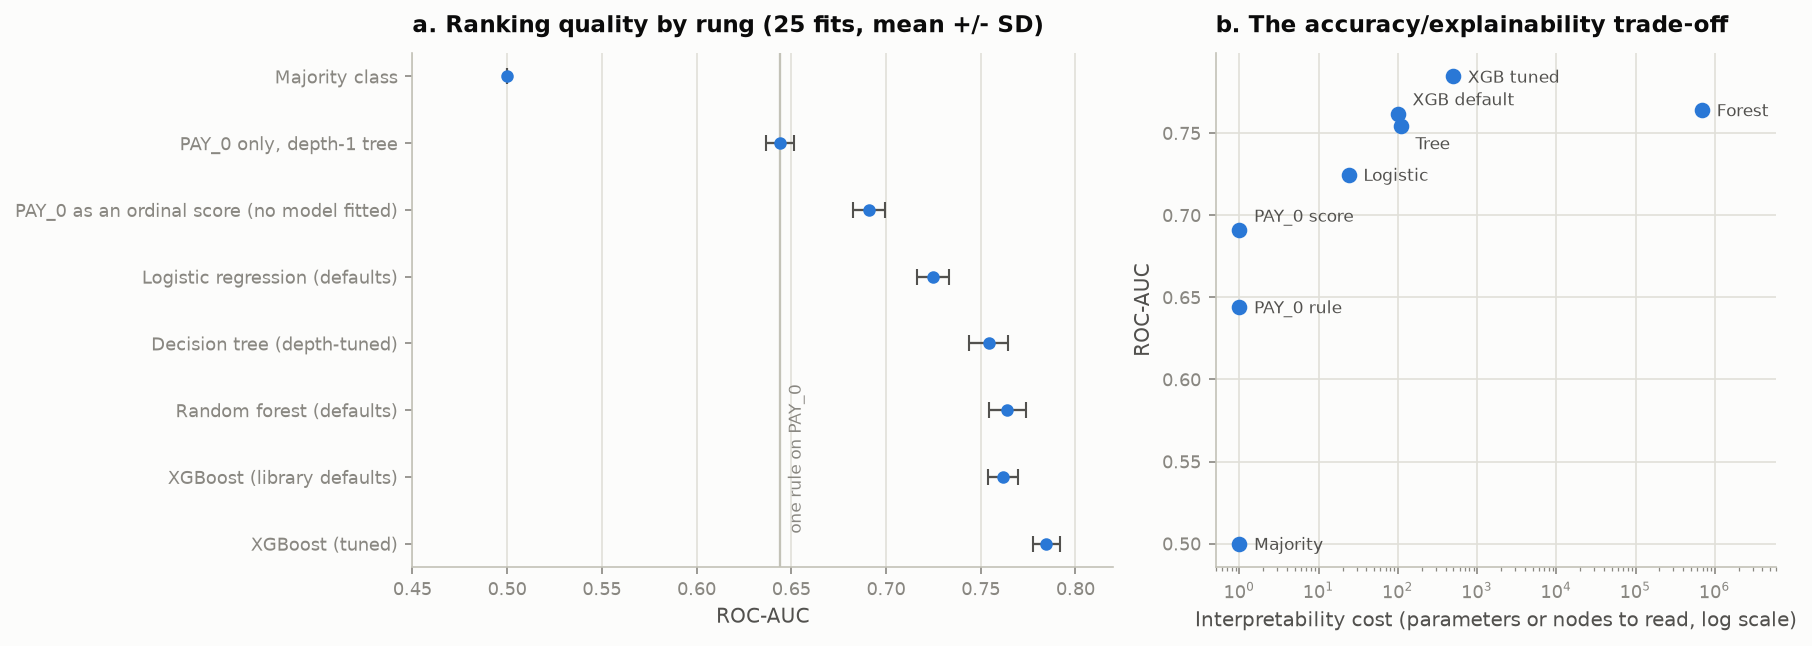

> Rung 0 reaches 77.8835% accuracy with zero recall, which is the accuracy trap in one line: the majority-class rate is 1 - prevalence = 77.8835%. Rung 1, a depth-1 tree on PAY_0, reaches only 0.6441 -- short of the 0.690 Phase 1 reported from the notebook that was never committed. The discrepancy is informative rather than an error: a single split binarises PAY_0 into two groups and discards the ordinal gradient, so rung 1b ranks on the raw code with no model at all and reaches 0.6910, recovering the benchmark. The +0.0468 between them is the measured price of insisting on one readable rule, and it is the first rung of the interpretability cost this experiment exists to quantify. Tuned XGBoost reaches 0.7845 +/- 0.0071, a gain of +0.1404 over a single readable rule and +0.0226 over untuned XGBoost. Bagging alone (rung 4) reaches 0.7641, so boosting contributes +0.0204 beyond bagging. Rungs 2 and 3 are untuned internal references, not the group's separately tuned Logistic Regression and Decision Tree submissions. Interpretability cost counts parameters or nodes a human must read to reproduce one decision; for the ensembles it is total node count across all trees, which is why it is reported as 'not directly available - see SHAP'.

In [3]:
show(report.table1_ladder(), "Table 1 — the complexity ladder (25 repeated-CV fits, mean ± SD)")
fig("p2_fig1_complexity_ladder", 1000)
notes("exp01_ladder")

---
## &sect;8 Tuning

Optuna's TPE sampler over eight hyperparameters. Grid search is wasteful in eight
dimensions and random search needs roughly three times the trials for equal quality;
TPE builds a density model of the good region and samples from it.

**ROC-AUC is the objective** (Lessmann et al., 2015): it is the declared primary metric,
it is prevalence-independent so it stays comparable across every rung of the ladder, and
it has lower fold-to-fold variance than PR-AUC. `aucpr` is logged every trial and
reported, but never optimised.

**`scale_pos_weight` is deliberately excluded from the search space.** ROC-AUC is
invariant to monotone score transformations and reweighting is approximately one, so the
tuner would be blind to it and pick arbitrarily. Fixing it per arm and tuning each arm
separately turns &sect;9 from a confound into a controlled comparison.

**Table 8.1 — tuned against library defaults**

Arm,Features,ROC-AUC,PR-AUC,Brier
tuned,23,0.7845 +/- 0.0071,0.5602 +/- 0.0146,0.13479 +/- 0.00414
library_defaults,23,0.7619 +/- 0.0080,0.5293 +/- 0.0113,0.14147 +/- 0.00257


**Table 8.2 — search ranges and the selected configuration**

Hyperparameter,Searched range,Type,Selected
max_depth,3 to 8,int,6
eta,0.01 to 0.3 (log),float,0.012533
min_child_weight,1.0 to 20.0 (log),float,4.1899
subsample,0.6 to 1.0,float,0.60358
colsample_bytree,0.5 to 1.0,float,0.7998
gamma,0.0 to 5.0,float,0.695
reg_lambda,0.01 to 100.0 (log),float,34.295
reg_alpha,0.001 to 10.0 (log),float,0.0015166


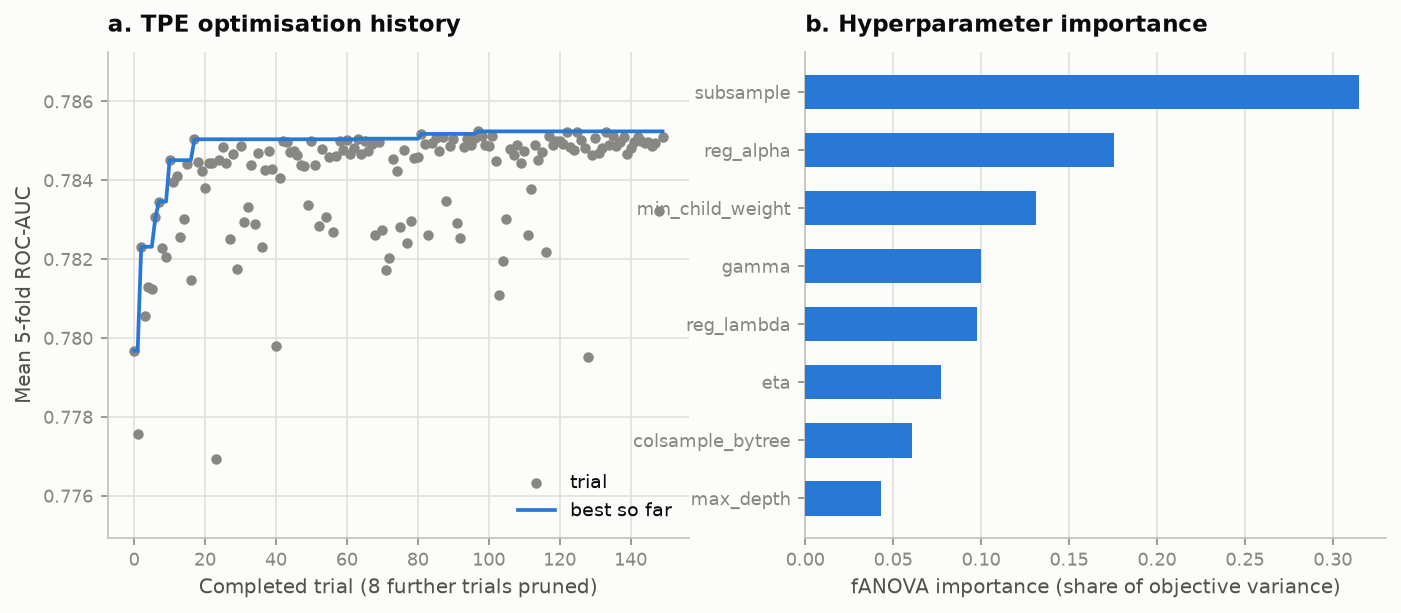

> Optuna TPE, 142 complete and 8 pruned trials, MedianPruner. Trial budget raised from the planned 60-80 to 150: measured cost was ~2.3 s per trial rather than the estimated 15-30 s, so a wider search was free. Tuning gain over library defaults on the 25 repeated-CV fits: +0.02265 ROC-AUC against a pooled fold-SD of 0.01067 (larger than one pooled SD). scale_pos_weight was excluded from the search space by design: ROC-AUC is invariant to monotone score transformations, so the tuner cannot see it. Early stopping used an inner 15% slice of each training fold, never the validation fold and never the test set.

In [4]:
p = report.load("exp02_tuning")
show(report.table_ablation("exp02_tuning"),
     "Table 8.1 — tuned against library defaults")
show(report.table_hyperparams(),
     "Table 8.2 — search ranges and the selected configuration")
fig("p2_app1_optuna", 1000)
notes("exp02_tuning")

---
## &sect;9 Class imbalance

At 22.1% positives this is mild imbalance, and the four arms are tuned independently so
`scale_pos_weight` is a controlled factor rather than a confound.

Read the **Brier** column, not the ROC-AUC column. That is where the arms differ, and it
is the column that matters, because &sect;11's cost analysis consumes probabilities rather
than a ranking.

In [5]:
show(report.table2_imbalance(), "Table 2 — class-imbalance strategies")
notes("exp03_imbalance")

**Table 2 — class-imbalance strategies**

Arm,spw,Sampler,tau,ROC-AUC,PR-AUC,Brier,OOF recall,OOF precision,OOF cost (r=6)
A_baseline,1.00,--,0.5000,0.7845 +/- 0.0071,0.5602 +/- 0.0146,0.13479 +/- 0.00414,0.3573,0.6775,"21,331"
B_threshold,1.00,--,0.1341,0.7845 +/- 0.0071,0.5602 +/- 0.0146,0.13479 +/- 0.00414,0.8288,0.3330,"14,239"
C_spw,3.52,--,0.5000,0.7848 +/- 0.0074,0.5581 +/- 0.0154,0.18009 +/- 0.00569,0.6342,0.4691,"15,431"
C_spw_threshold,3.52,--,0.3580,0.7848 +/- 0.0074,0.5581 +/- 0.0154,0.18009 +/- 0.00569,0.8190,0.3390,"14,215"
D_smote,1.00,SMOTE,0.4720,0.7681 +/- 0.0088,0.5218 +/- 0.0171,0.22004 +/- 0.01565,0.8111,0.3245,"14,952"


> Reweighting changes ranking by +0.00031 ROC-AUC against a fold-SD of 0.00712, so A and C are not distinguishable on ranking. Calibration does move: Brier 0.13479 (spw=1) versus 0.18009 (spw=3.52), a +0.04529 change. This is a mechanistic result, not a null one: reweighting and threshold-moving are two parameterisations of the same decision shift, but only threshold-moving preserves probability semantics, and the cost analysis in WP14 consumes probabilities. SMOTE reaches 0.76811 (-0.01643 versus A) and is rejected on dataset-specific grounds rather than generic ones: interpolating two clients produces values such as PAY_0 = 0.37, a repayment code that does not exist, and Phase 1 established PAY_n is non-monotonic and categorical-like. max_delta_step was considered and dismissed -- it addresses imbalance beyond roughly 100:1, and this dataset is 3.5:1. Thresholds were frozen from out-of-fold training predictions at r=6; the test set is not touched by this experiment.

---
## &sect;10 Feature studies

Four questions, each of which Phase 1 either raised explicitly or left open.

### &sect;10.1 Encoding of the ordinal `PAY_n` columns

Phase 1 established `PAY_n` is non-monotonic, which is normally the argument for one-hot
encoding. It does not apply to trees: axis-aligned splits recover a non-monotonic response
by *stacking* (`PAY_0 < 0.5`, then `PAY_0 < -1.5`), which costs depth rather than
expressible functions. Native integers also keep the six columns distinct, which protects
the recency gradient examined in &sect;10.4.

In [6]:
show(report.table_ablation("exp04_encoding"), "Table A1 — encoding ablation")
notes("exp04_encoding")

**Table A1 — encoding ablation**

Arm,Features,ROC-AUC,PR-AUC,Brier
native_int,23,0.7845 +/- 0.0071,0.5602 +/- 0.0146,0.13479 +/- 0.00414
one_hot,79,0.7837 +/- 0.0089,0.5532 +/- 0.0182,0.13635 +/- 0.00758
native_categorical,23,0.7854 +/- 0.0075,0.5611 +/- 0.0145,0.13380 +/- 0.00228
signed_log_monetary,23,0.7845 +/- 0.0071,0.5602 +/- 0.0146,0.13479 +/- 0.00414


> All four encodings sit within 0.00175 ROC-AUC of each other against a fold-SD of 0.00712, so none is distinguishable from native integers. Native integers are carried forward. Trees make axis-aligned splits, so a non-monotonic response to PAY_n is recoverable by stacking splits (PAY_0 < 0.5, then PAY_0 < -1.5) -- that costs depth, not expressible functions. Integers also keep the six PAY_n columns distinct, protecting the recency gradient Phase 1 measured (Spearman rho 0.143 rising to 0.292). One-hot expands to 79 columns for no measurable gain. The signed-log arm confirms scale invariance: a monotone transform of every monetary column moves ROC-AUC by +0.00000, because axis-aligned splits depend only on rank order. Paired per-fold t-tests are reported, with the Nadeau-Bengio (2003) caveat that repeated-CV tests are anti-conservative because the training folds overlap. Note that enable_categorical=True blocks interventional TreeSHAP in shap 0.52, which is a second reason to prefer integers for a model that must be explained.

### &sect;10.2 Engineered features

Phase 1 &sect;2.2.2 committed to *benchmarking* aggregate features rather than assuming
they help, and predicted that aggregation would **lose** signal by collapsing the recency
gradient into a single scalar. This tests that prediction.

**Table A2 — engineered features**

Arm,Features,ROC-AUC,PR-AUC,Brier
raw_23,23,0.7845 +/- 0.0071,0.5602 +/- 0.0146,0.13479 +/- 0.00414
raw_plus_engineered,40,0.7880 +/- 0.0073,0.5624 +/- 0.0154,0.13618 +/- 0.00776
engineered_only,17,0.7786 +/- 0.0075,0.5416 +/- 0.0146,0.13742 +/- 0.00648
rfe_top23,23,0.7869 +/- 0.0073,0.5600 +/- 0.0130,0.13756 +/- 0.00972


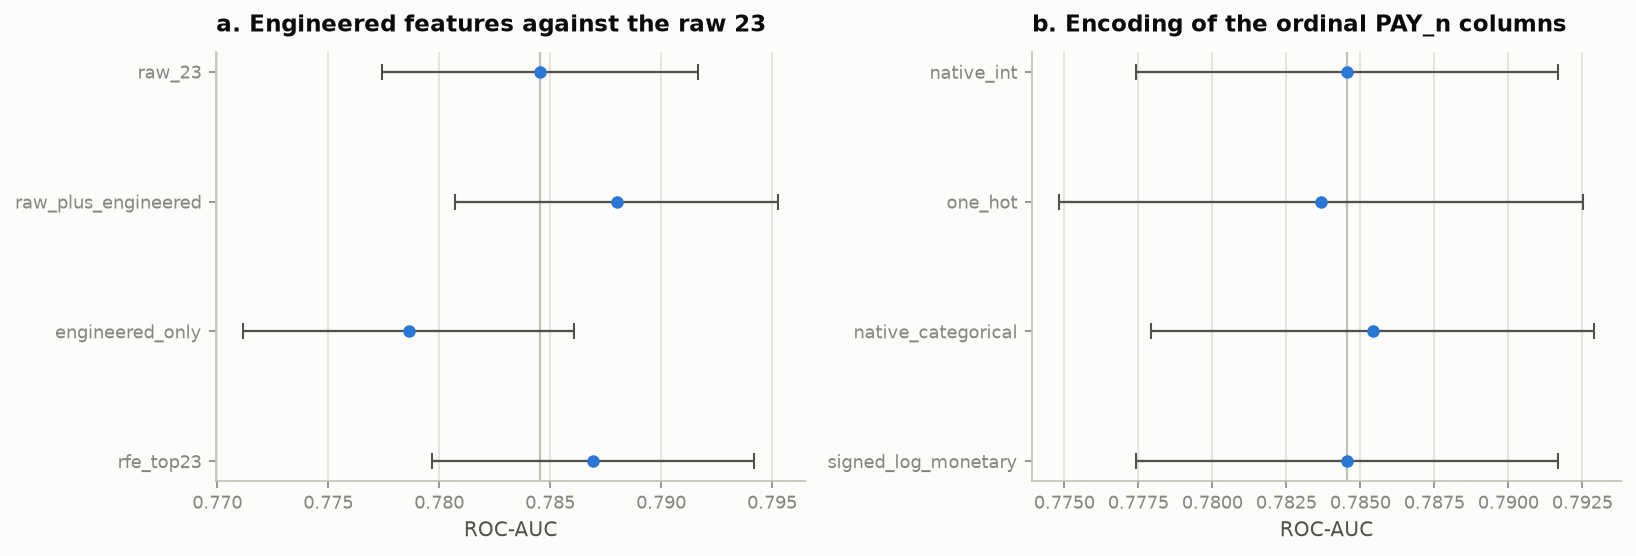

> Adding the 17 engineered features to the raw 23 moves ROC-AUC by +0.00345 against a fold-SD of 0.00712. Replacing the raw columns entirely with the engineered ones moves it by -0.00592. Phase 1 predicted aggregation would lose the recency gradient; on this evidence that prediction is neither confirmed nor refuted at the one-SD level. RFE to 23 features from the combined pool provides an equal-width comparison, so the raw-plus-engineered arm is not simply rewarded for having more columns. PAY_RATIO_n is NaN where the statement balance is zero or negative (1,930 rows carry a negative BILL_AMT per Phase 1 section 1.6); XGBoost learns a default direction for missing values natively rather than requiring imputation, which is why NaN was preferred to a sentinel.

In [7]:
show(report.table_ablation("exp05_engineered"), "Table A2 — engineered features")
fig("p2_app8_engineered_encoding", 1000)
notes("exp05_engineered")

### &sect;10.3 Feature-group ablation

Leave-one-group-out beside only-one-group, over the five groups of `FEATURE_GROUPS`.
Leave-one-out understates a group's value whenever another group proxies for it, and
only-one overstates it; reading both together is what locates the signal. The
`drop_demographic` arm is consumed again by &sect;13.

**Table A3 — feature-group ablation**

Arm,Features,ROC-AUC,PR-AUC,Brier
all_groups,23,0.7845 +/- 0.0071,0.5602 +/- 0.0146,0.13479 +/- 0.00414
drop_demographic,19,0.7832 +/- 0.0075,0.5574 +/- 0.0140,0.13655 +/- 0.00815
drop_limit,22,0.7769 +/- 0.0079,0.5537 +/- 0.0147,0.13842 +/- 0.00952
drop_pay_status,17,0.7374 +/- 0.0075,0.4586 +/- 0.0139,0.14970 +/- 0.00402
drop_bill,17,0.7781 +/- 0.0076,0.5527 +/- 0.0160,0.13727 +/- 0.00809
drop_pay_amt,17,0.7824 +/- 0.0086,0.5551 +/- 0.0185,0.13899 +/- 0.01116
only_demographic,4,0.5646 +/- 0.0086,0.2581 +/- 0.0081,0.17183 +/- 0.00036
only_limit,1,0.6175 +/- 0.0095,0.2966 +/- 0.0078,0.16943 +/- 0.00187
only_pay_status,6,0.7492 +/- 0.0080,0.5236 +/- 0.0154,0.14845 +/- 0.00863
only_bill,6,0.6331 +/- 0.0112,0.3338 +/- 0.0144,0.16568 +/- 0.00199


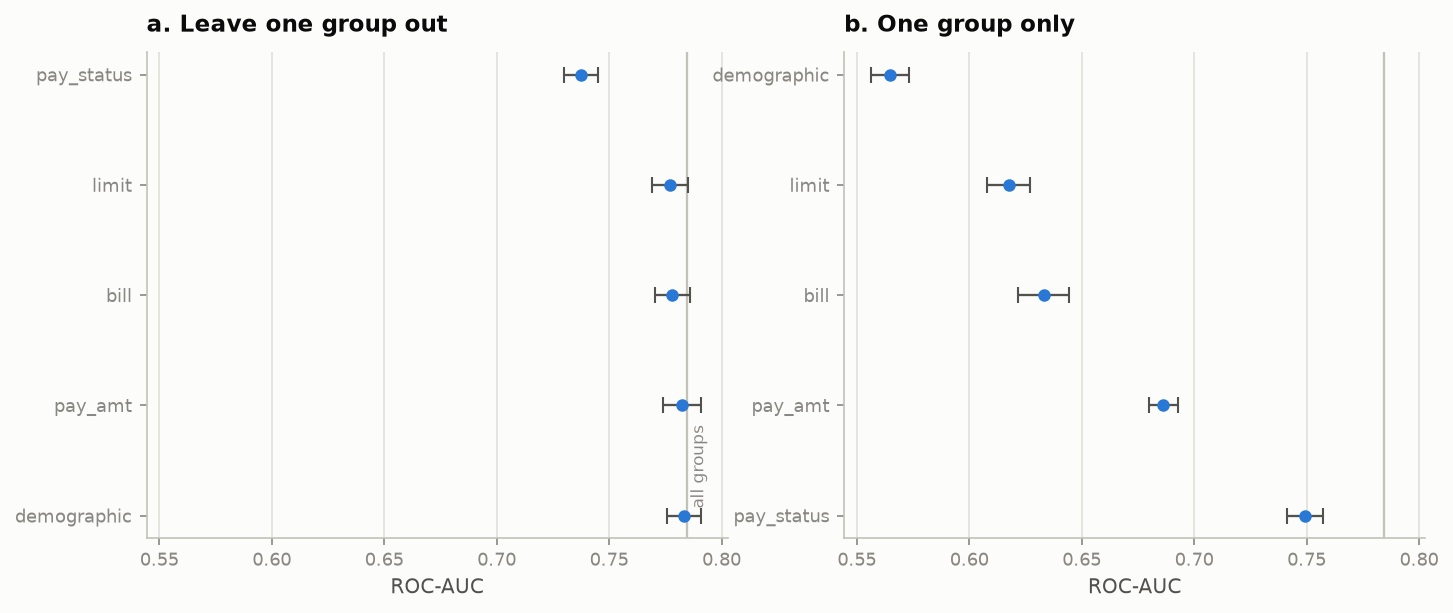

> Removing pay_status costs 0.04719 ROC-AUC, the largest leave-one-out loss, against a fold-SD of 0.00712. pay_status alone reaches 0.74915 versus 0.78454 for the full feature set, so it carries most of the available signal on its own. This confirms the Phase 1 conclusion that repayment status dominates the monetary columns. Leave-one-out and only-one disagree in the usual way: a group can be individually predictive yet redundant once the others are present, which is exactly what collinear BILL_AMT columns produce. Both views are reported rather than one. Dropping the demographic group costs +0.00132 ROC-AUC; the drop_demographic arm is consumed by WP17, which tests whether the financial columns proxy for the removed demographics (Barocas & Selbst, 2016).

In [8]:
show(report.table_ablation("exp06_groups"), "Table A3 — feature-group ablation")
fig("p2_app4_feature_groups", 1000)
notes("exp06_groups")

### &sect;10.4 Recency and data volume

Two practical questions a lender would actually ask: how many months of repayment history
are worth collecting, and would more clients help? The learning curve answers the second,
and it is the evidence for the feature-set-ceiling claim in &sect;14.

**Table A4 — recency ablation**

Arm,Features,ROC-AUC,PR-AUC,Brier,k_months
k1_months,8,0.7669 +/- 0.0084,0.5331 +/- 0.0164,0.14455 +/- 0.01190,1
k2_months,11,0.7743 +/- 0.0083,0.5428 +/- 0.0169,0.14012 +/- 0.01095,2
k3_months,14,0.7786 +/- 0.0077,0.5474 +/- 0.0150,0.14397 +/- 0.01339,3
k4_months,17,0.7828 +/- 0.0081,0.5558 +/- 0.0186,0.13776 +/- 0.00862,4
k5_months,20,0.7842 +/- 0.0077,0.5589 +/- 0.0139,0.13558 +/- 0.00639,5
k6_months,23,0.7833 +/- 0.0069,0.5570 +/- 0.0126,0.13841 +/- 0.00905,6


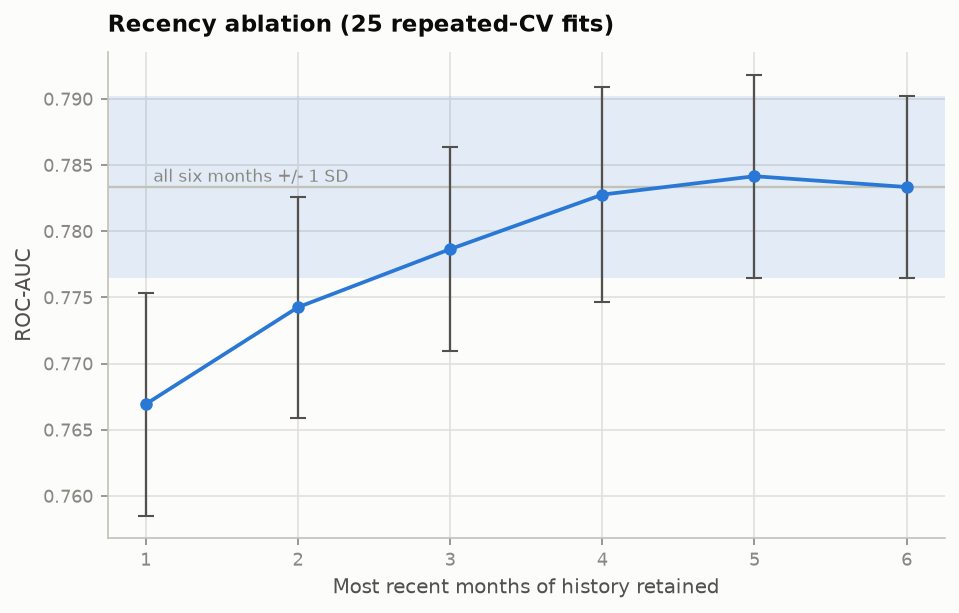

> One month of history (September only) already reaches ROC-AUC 0.76694, against 0.78334 for all six months -- a total gain of +0.01640 from five extra months, against a fold-SD of 0.00689. k=3 is the smallest history window that lands within one fold-SD of the full six months, so most of the collectable signal is in the most recent statement. This is the recency gradient of Phase 1 (Spearman rho rising from 0.143 at April to 0.292 at September) restated as a data-collection cost. Marginal gain per additional month: k2: +0.00732, k3: +0.00439, k4: +0.00412, k5: +0.00139, k6: -0.00082. Practical reading for a lender: the fifth and sixth months of history are close to free of predictive value here, which matters because history depth is an acquisition cost and a privacy exposure, not just a modelling choice.

**Table A5 — learning curve**

Arm,Features,ROC-AUC,PR-AUC,Brier,fraction,train_roc_auc_mean,gap_train_minus_val
frac_0.10,23,0.7633 +/- 0.0085,--,--,+0.1000,+0.8043,+0.0410
frac_0.25,23,0.7736 +/- 0.0060,--,--,+0.2500,+0.8066,+0.0330
frac_0.50,23,0.7784 +/- 0.0070,--,--,+0.5000,+0.8133,+0.0349
frac_0.75,23,0.7824 +/- 0.0049,--,--,+0.7500,+0.8178,+0.0354
frac_1.00,23,0.7835 +/- 0.0059,--,--,+1.0000,+0.8157,+0.0322


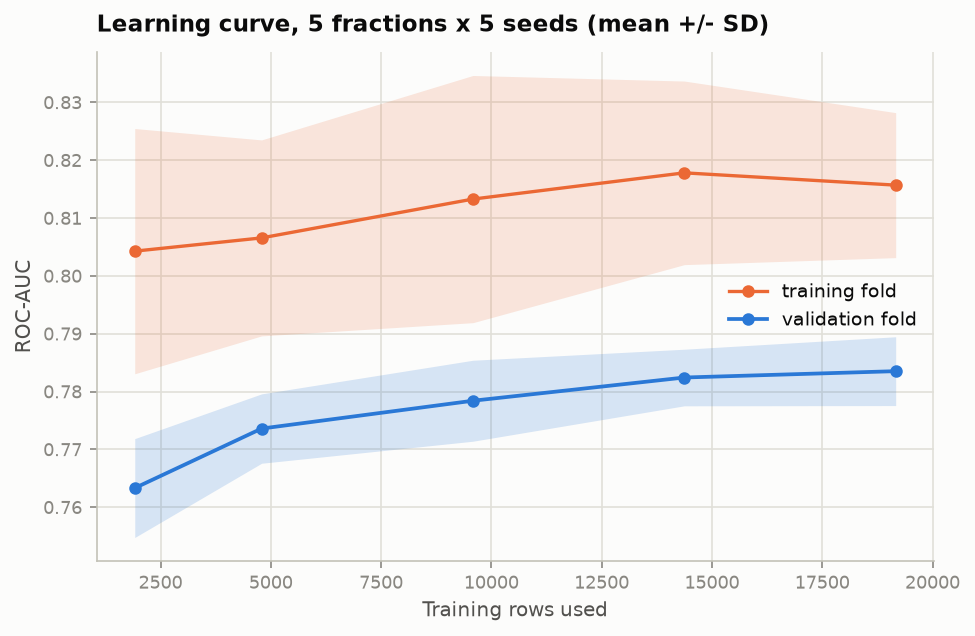

> Validation ROC-AUC rises from 0.76331 at 10% of the training data to 0.78352 at 100%. Half the data already reaches 0.77841, and the final step from 75% to 100% adds +0.00110 against a fold-SD of 0.00595. The curve has therefore flattened: more rows of the same six-month billing snapshot would not materially help. The train-validation gap at full data is +0.03217, so the plateau is a feature-set ceiling rather than a high-variance overfit that more data would close. Together with the small tuned-versus-untuned gap from exp02, this is the evidence behind the WP18 argument that performance is limited by what a billing snapshot can observe -- it cannot see job loss, illness or income shocks -- not by model capacity.

In [9]:
show(report.table_ablation("exp07_recency", ["k_months"]), "Table A4 — recency ablation")
fig("p2_app3_recency", 720)
notes("exp07_recency")
show(report.table_ablation("exp08_learning_curve",
                           ["fraction", "train_roc_auc_mean", "gap_train_minus_val"]),
     "Table A5 — learning curve")
fig("p2_app2_learning_curve", 720)
notes("exp08_learning_curve")

---
## &sect;11 Calibration and cost

### &sect;11.1 Calibration

Mandatory rather than optional: &sect;11.2 chooses a threshold by minimising expected
cost, which is an operation on probabilities. If the probabilities are not calibrated, the
cost curve is minimising the wrong quantity.

**Table A6 — calibration: Brier and expected calibration error**

Arm,Features,ROC-AUC,PR-AUC,Brier,arm,method,ece
A_spw1_raw,23,0.7776,0.5494,0.13558,A_spw1,raw,+0.0212
A_spw1_sigmoid,23,0.7812,0.5536,0.13485,A_spw1,sigmoid,+0.0191
A_spw1_isotonic,23,0.7783,0.5458,0.13494,A_spw1,isotonic,+0.0102
C_spw_raw,23,0.7796,0.5492,0.18121,C_spw,raw,+0.2088
C_spw_sigmoid,23,0.7815,0.5475,0.13460,C_spw,sigmoid,+0.0115
C_spw_isotonic,23,0.7794,0.5450,0.13478,C_spw,isotonic,+0.0080


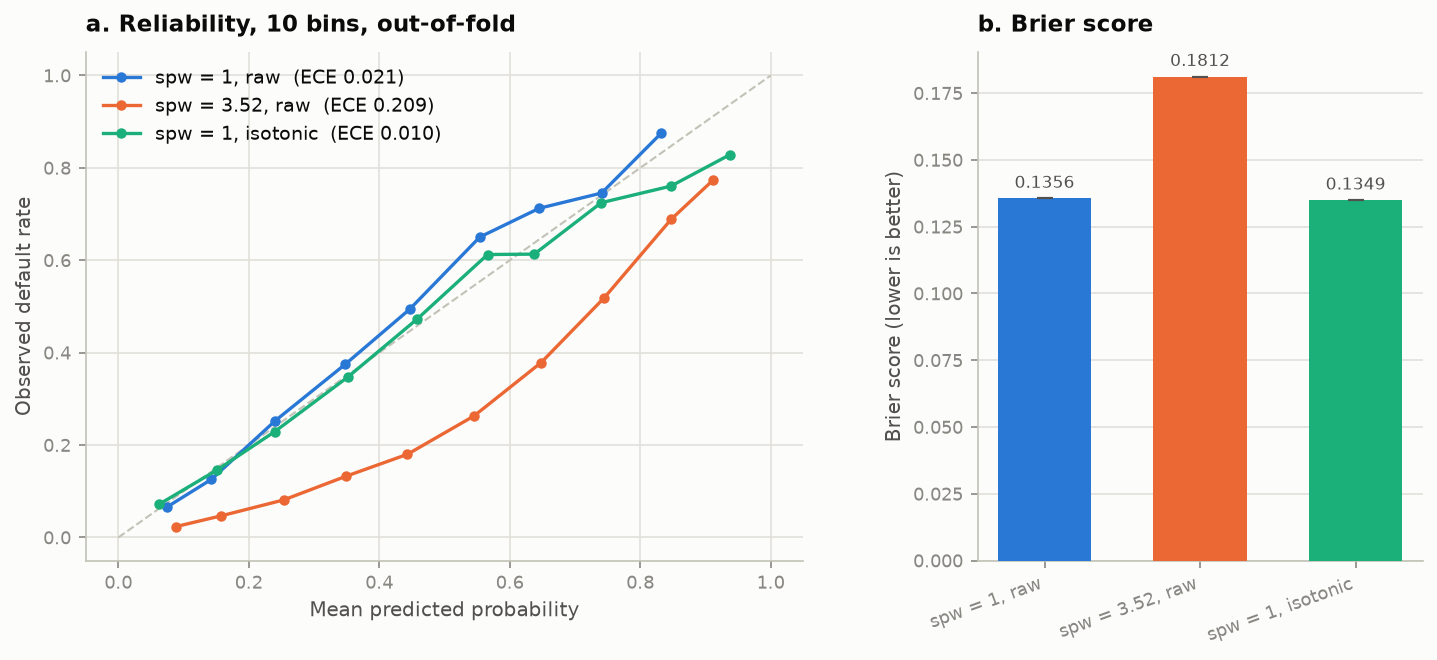

> Prevalence is 0.2212. The spw=1 model predicts a mean probability of 0.2189 -- essentially the base rate -- with Brier 0.13558 and ECE 0.02121. Reweighting to spw=3.52 inflates the mean prediction to 0.4299 and worsens Brier to 0.18121 (ECE 0.20878), because scale_pos_weight shifts the score distribution without changing the underlying event rate. That is the concrete cost of reweighting that ROC-AUC cannot see. Best Brier overall: C_spw_sigmoid at 0.13460. Arm B of exp03 is omitted here because it is arm A's fitted model read at a different threshold -- its probabilities are identical, which is precisely why threshold-moving is preferable to reweighting when probabilities are consumed downstream. Reliability curves (10 equal-width bins) are serialised in config for WP19.

In [10]:
show(report.table_ablation("exp09_calibration", ["arm", "method", "ece"]),
     "Table A6 — calibration: Brier and expected calibration error")
fig("p2_fig3_reliability", 950)
notes("exp09_calibration")

### &sect;11.2 Cost-sensitive threshold selection

The cost ratio is anchored in credit-risk parameters rather than chosen for convenience.
A false negative costs loss-given-default times exposure-at-default; a false positive
costs the forgone net interest margin. Retail unsecured LGD &asymp; 0.70 and NIM &asymp;
0.12 give r = 5.83, reported as 6:1.

The sweep is overlaid with **Elkan's (2001) analytic optimum** p\* = 1/(1+r). If the
empirical out-of-fold optimum tracks the analytic curve, that is direct evidence the
probabilities carry the right *scale* and not merely the right *ranking* &mdash; which
ties &sect;11.1, &sect;11.2 and the threshold-freezing protocol of &sect;6 into one result.

**Table 3 — cost sweep, flat per-error costing**

r = C_FN/C_FP,Elkan p* = 1/(1+r),Empirical OOF tau,tau - p*,Recall,Precision,Min cost,Cost @0.5,Saving
1,0.5000,0.5360,+0.0360,0.3350,0.6994,"4,286","4,306",20
2,0.3333,0.3180,-0.0153,0.5289,0.5605,"7,189","7,711",522
5,0.1667,0.1781,+0.0114,0.7191,0.4076,"12,978","17,926","4,948"
6,0.1429,0.1341,-0.0088,0.8288,0.3330,"14,239","21,331","7,092"
10,0.0909,0.0841,-0.0068,0.9471,0.2670,"16,575","34,951","18,376"
20,0.0476,0.0541,+0.0065,0.9900,0.2358,"18,058","69,001","50,943"


**Table A7 — cost sweep, instance-specific costing (LIMIT_BAL as an EAD proxy)**

r = C_FN/C_FP,Elkan p* = 1/(1+r),Empirical OOF tau,tau - p*,Recall,Precision,Min cost,Cost @0.5,Saving
1,0.5000,0.1621,-0.3379,0.7541,0.3792,"259,487,440","360,312,320","100,824,880"
2,0.3333,0.1621,-0.1713,0.7541,0.3792,"259,487,440","360,312,320","100,824,880"
5,0.1667,0.1621,-0.0046,0.7541,0.3792,"259,487,440","360,312,320","100,824,880"
6,0.1429,0.1621,+0.0192,0.7541,0.3792,"259,487,440","360,312,320","100,824,880"
10,0.0909,0.1621,+0.0712,0.7541,0.3792,"259,487,440","360,312,320","100,824,880"
20,0.0476,0.1621,+0.1144,0.7541,0.3792,"259,487,440","360,312,320","100,824,880"


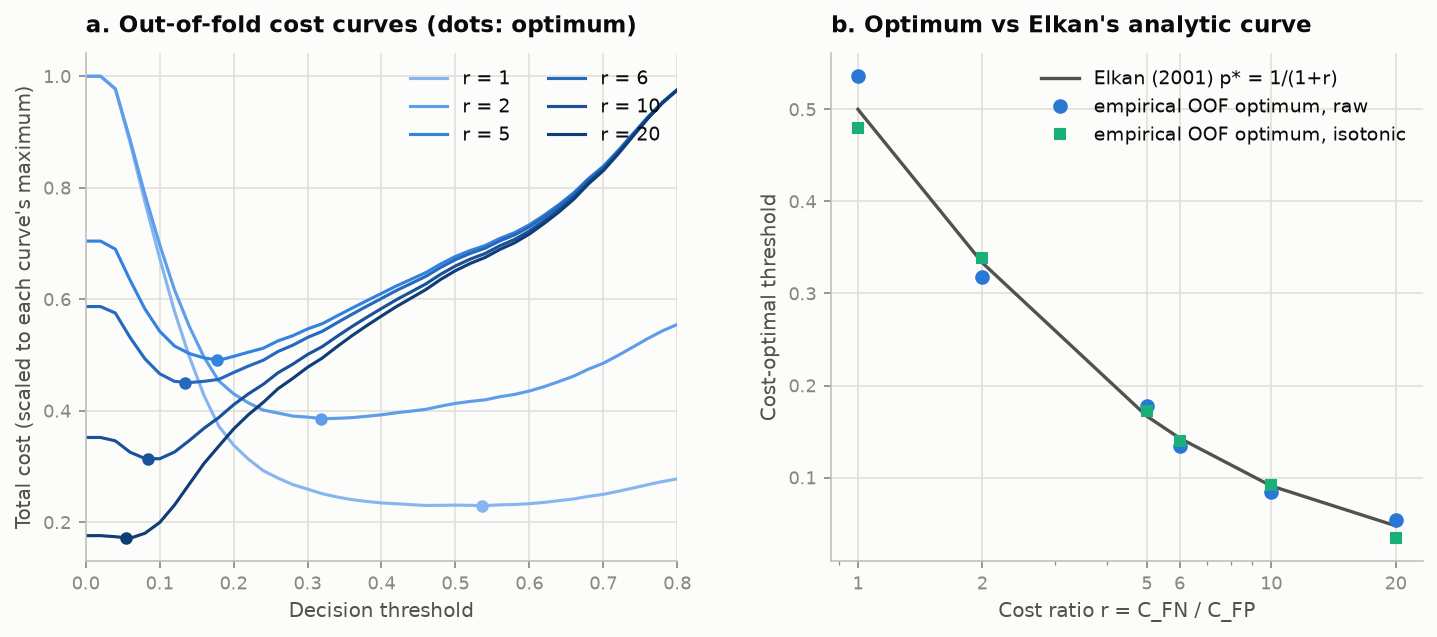

> Cost ratio derived from credit-risk parameters: LGD=0.7 and NIM=0.12 give r = 5.83, reported as 6:1. At r=6, Elkan's analytic optimum is p* = 1/(1+r) = 0.1429 and the empirical out-of-fold optimum is 0.1341, a difference of -0.0088. Mean absolute deviation from the analytic curve across the whole sweep is 0.0141 for raw probabilities and 0.0079 after isotonic calibration, so calibration tightens the agreement. That the empirical optimum tracks 1/(1+r) at all is direct evidence the probabilities carry the right scale, not merely the right ranking. Moving from the default 0.5 to the frozen threshold at r=6 saves 7,092 cost units and lifts recall from 0.3350 at r=1 to 0.8288. Instance-specific costing using LIMIT_BAL as an EAD proxy selects 0.1621 instead of 0.1341: weighting each error by exposure shifts the optimum because large-limit defaults dominate the loss. Both schemes are reported. The 9.8M-customer and $1.17bn figures from the proposal are motivation for caring about cost asymmetry; they are not presented as a result of this model.

In [11]:
show(report.table3_cost("flat"), "Table 3 — cost sweep, flat per-error costing")
show(report.table3_cost("instance"),
     "Table A7 — cost sweep, instance-specific costing (LIMIT_BAL as an EAD proxy)")
fig("p2_fig4_cost_threshold", 1000)
notes("exp10_cost")

---
## &sect;12 SHAP &mdash; research question 2

Explanations are computed on **held-out** rows, because "can post-hoc explanation provide
regulatory-compliant decision auditability" is a question about decisions the model was
not fitted on. Attribution is in log-odds (margin) space, where TreeSHAP is exactly
additive; the probability transform is non-additive and is used only for the single-client
waterfalls.

`feature_perturbation="interventional"` breaks the dependence between a feature and its
correlates, which is the right choice when the question is *what did the model use*
rather than *what does the data imply*.

**Table 4 — top-10 attribution, with cross-measure rank agreement**

Rank,Feature,mean|SHAP| (log-odds),Share,Mean SHAP,Group,Rank SD (5 seeds),Gain rank,Permutation rank
1,PAY_0,0.3780,22.3%,-0.0061,pay_status,0.00,1,1
2,LIMIT_BAL,0.2078,12.3%,-0.0287,other,0.00,8,2
3,BILL_AMT1,0.1254,7.4%,+0.0154,bill,0.45,10,3
4,PAY_AMT2,0.1087,6.4%,+0.0136,other,0.55,7,22
5,PAY_AMT1,0.0966,5.7%,-0.0140,other,1.41,9,16
6,PAY_2,0.0907,5.3%,+0.0105,pay_status,1.10,2,11
7,PAY_3,0.0837,4.9%,+0.0059,pay_status,1.00,3,9
8,PAY_AMT3,0.0816,4.8%,-0.0181,other,0.55,11,8
9,PAY_4,0.0609,3.6%,-0.0019,pay_status,0.55,4,5
10,PAY_AMT6,0.0524,3.1%,+0.0014,other,2.77,15,23


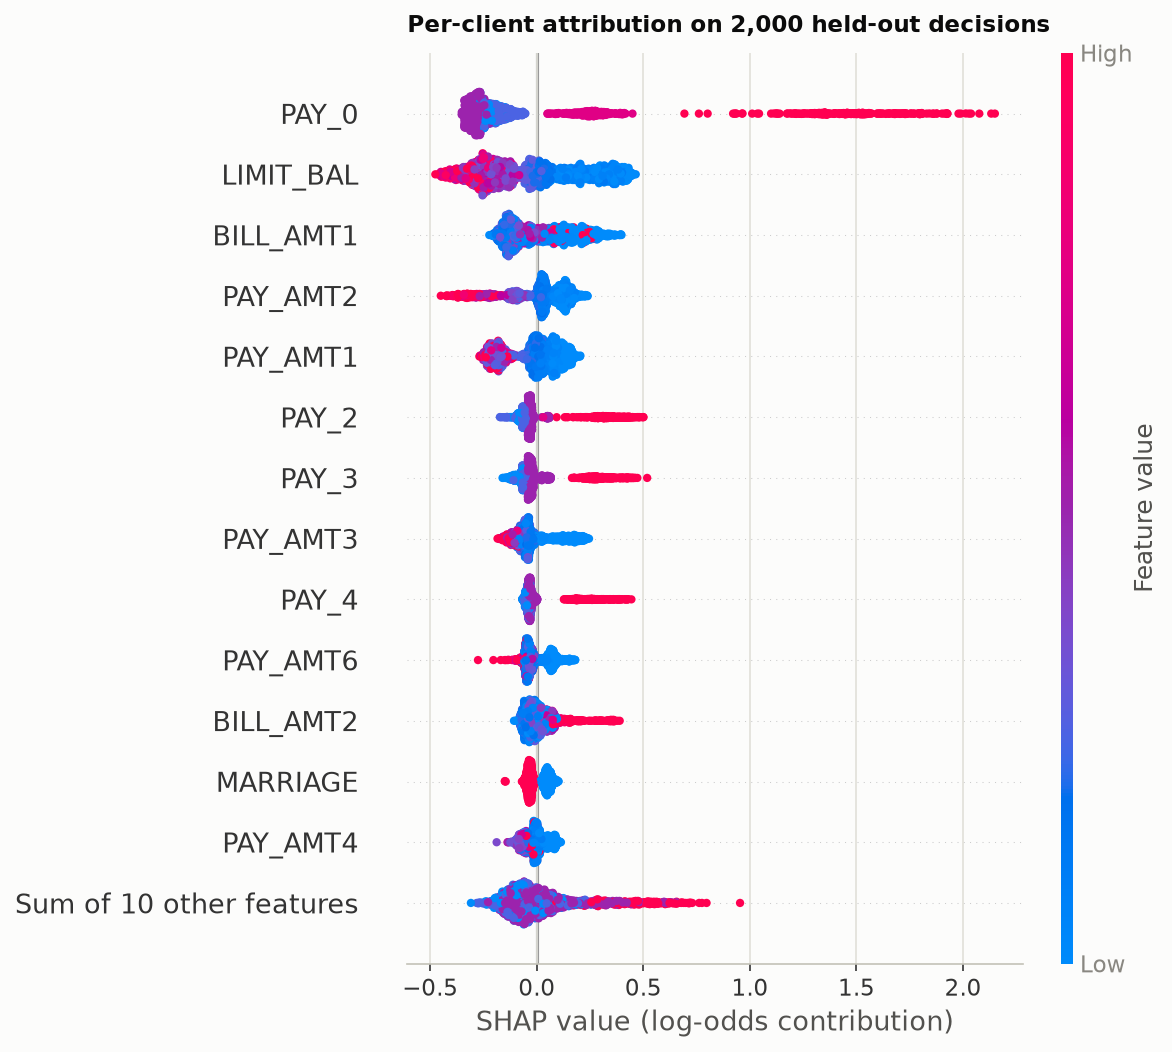

> TreeSHAP on 2,000 stratified held-out rows with a 1000-row stratified background from train. Additivity holds to 3.7e-06 in log-odds space. Interventional and path-dependent mean|SHAP| rankings agree at Spearman rho 0.9733. Top five by mean|SHAP|: PAY_0, LIMIT_BAL, BILL_AMT1, PAY_AMT2, PAY_AMT1. Repayment-status columns carry 40.2% of total attribution against 16.5% for the six BILL_AMT columns. Convergent validation: mean SHAP by PAY_0 code correlates with the observed default rate at Spearman rho 0.7000, so the model's internals independently reproduce the non-monotonic gradient Phase 1 measured in the raw data (12.8% at -1, 16.8% at 0, 34.0% at 1, 69.2% at 2). The model was never told PAY_n is ordinal; it recovered the shape from the data. Caveat on collinearity: BILL_AMT1-6 carry VIF 13.9-25.7 (Phase 1 Fig 2.14), so TreeSHAP splits credit arbitrarily among them. Individual BILL_AMT attributions are unstable and must be read as a group total, not per column. Caveat on interpretation: SHAP attributes the model's output, not a causal mechanism -- it answers 'why did this model decide that', which is the auditability question, and not 'what would happen if we changed this'.

In [12]:
show(report.table4_shap(10),
     "Table 4 — top-10 attribution, with cross-measure rank agreement")
fig("p2_fig5_shap_beeswarm", 760)
notes("exp11_shap")

### &sect;12.1 Convergent validation of the Phase 1 gradient

The most valuable figure in this report. The model was never told `PAY_n` is ordinal, and
never shown the Phase 1 default-rate table. Yet its internal response to `PAY_0` dips at
&minus;1 and 0 and jumps at 1 and 2, reproducing the 12.8% &rarr; 16.8% &rarr; 34.0%
&rarr; 69.2% gradient Phase 1 measured directly in the raw data.

Two independent methods &mdash; a contingency table on raw data and a game-theoretic
attribution of a gradient-boosted ensemble &mdash; agreeing on the same non-monotonic
shape is convergent validation, not a coincidence.

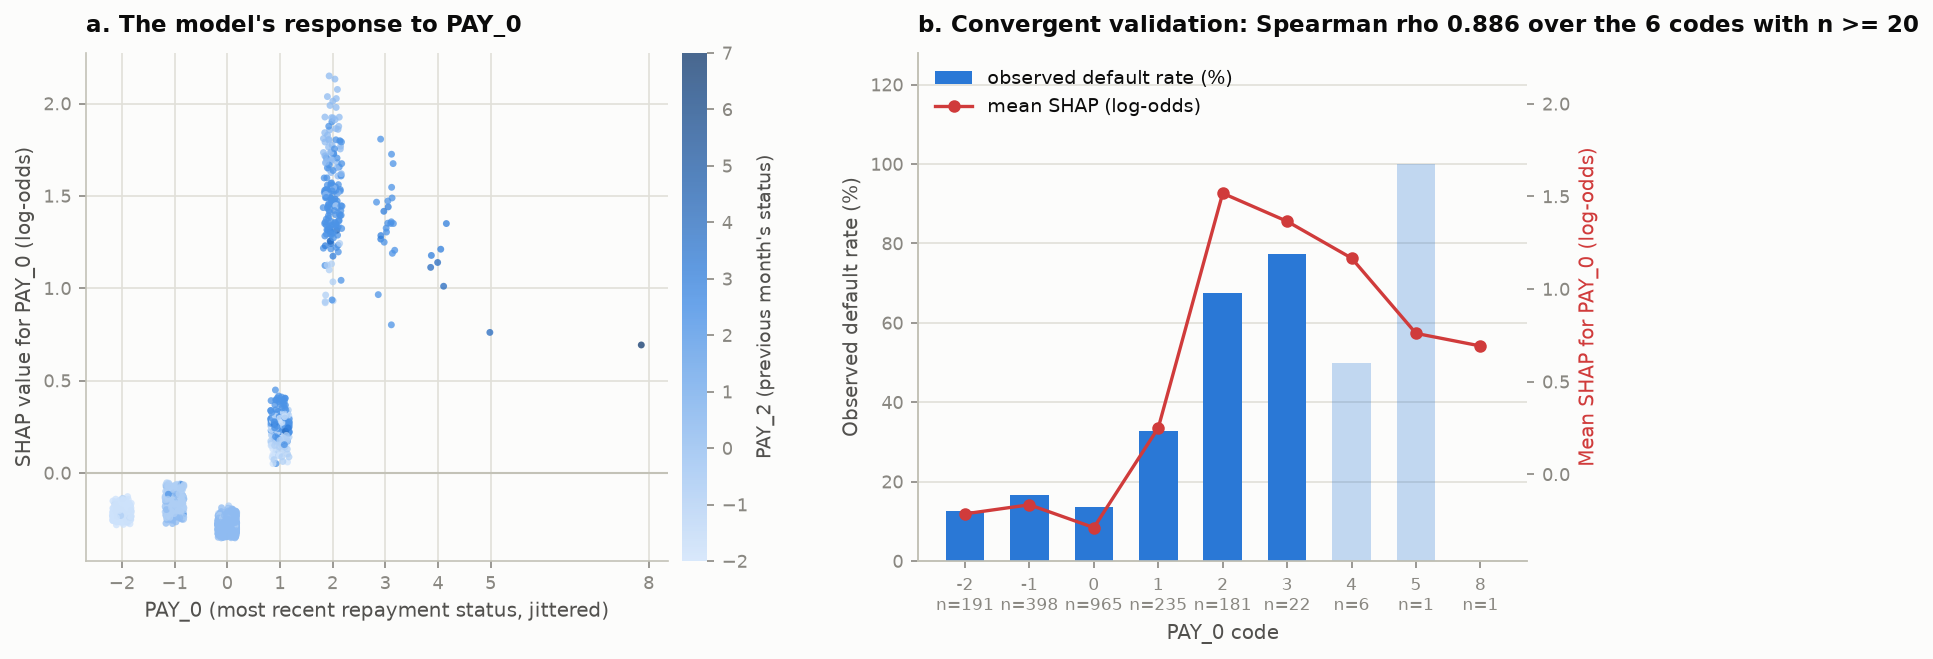

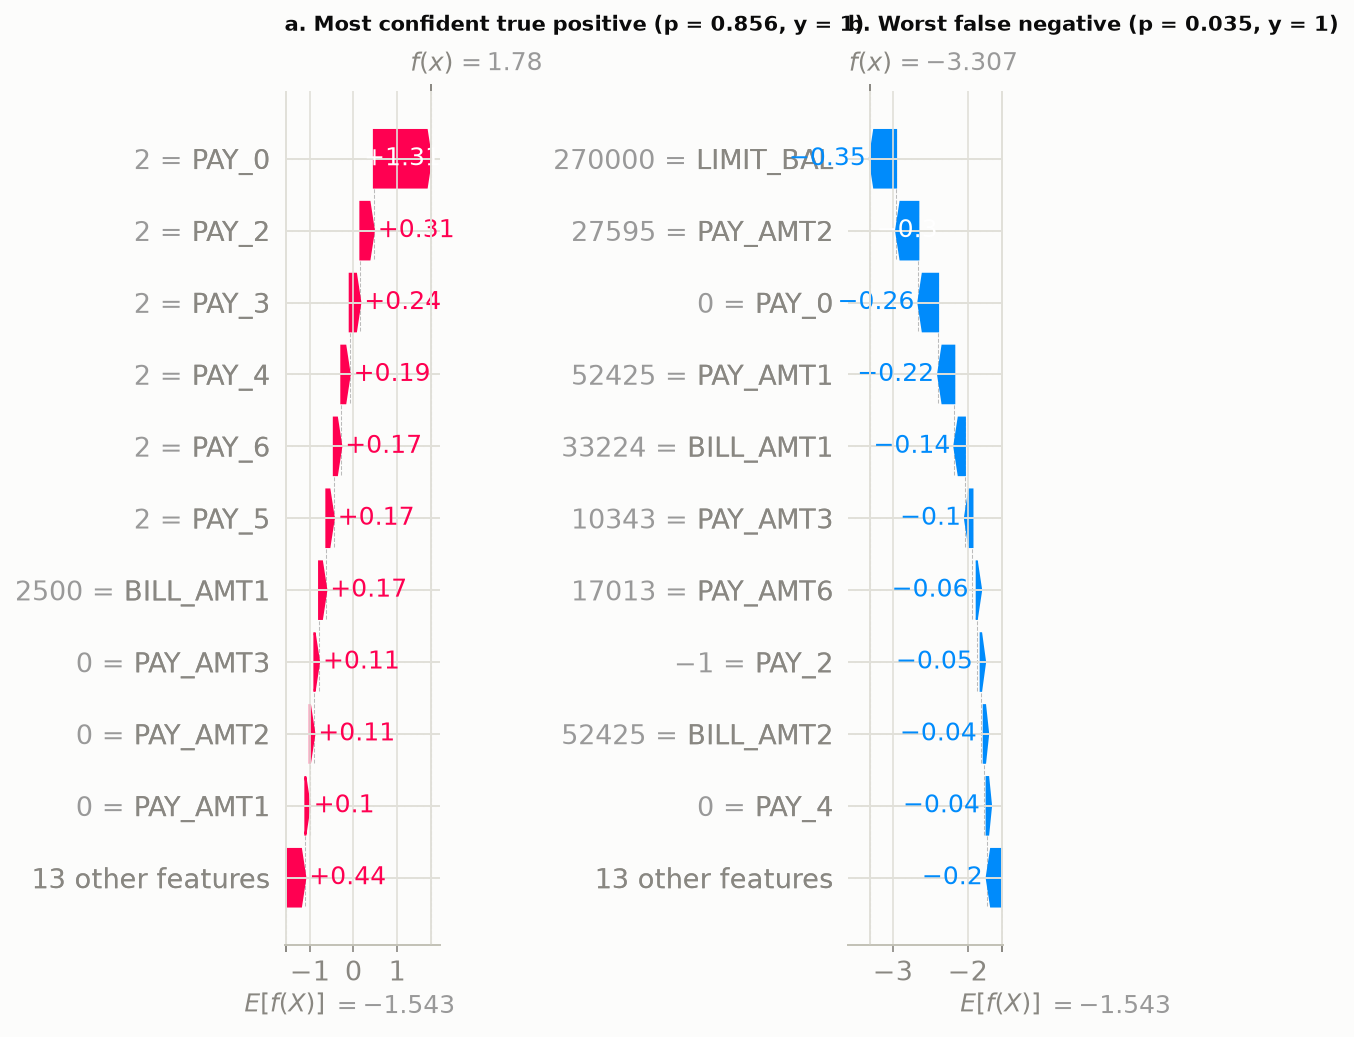

In [13]:
fig("p2_fig6_shap_pay0_dependence", 1000)
fig("p2_app5_shap_waterfalls", 1050)

### &sect;12.2 Is the explanation fit for audit?

This is the part of research question 2 with teeth. An explanation that reorders when the
model is reseeded is not an audit trail, and five importance measures that disagree cannot
all be the basis of a regulatory disclosure.

Across 5 reseeded refits: mean pairwise Spearman rho **0.9375**, mean top-10 Jaccard **0.8727**.

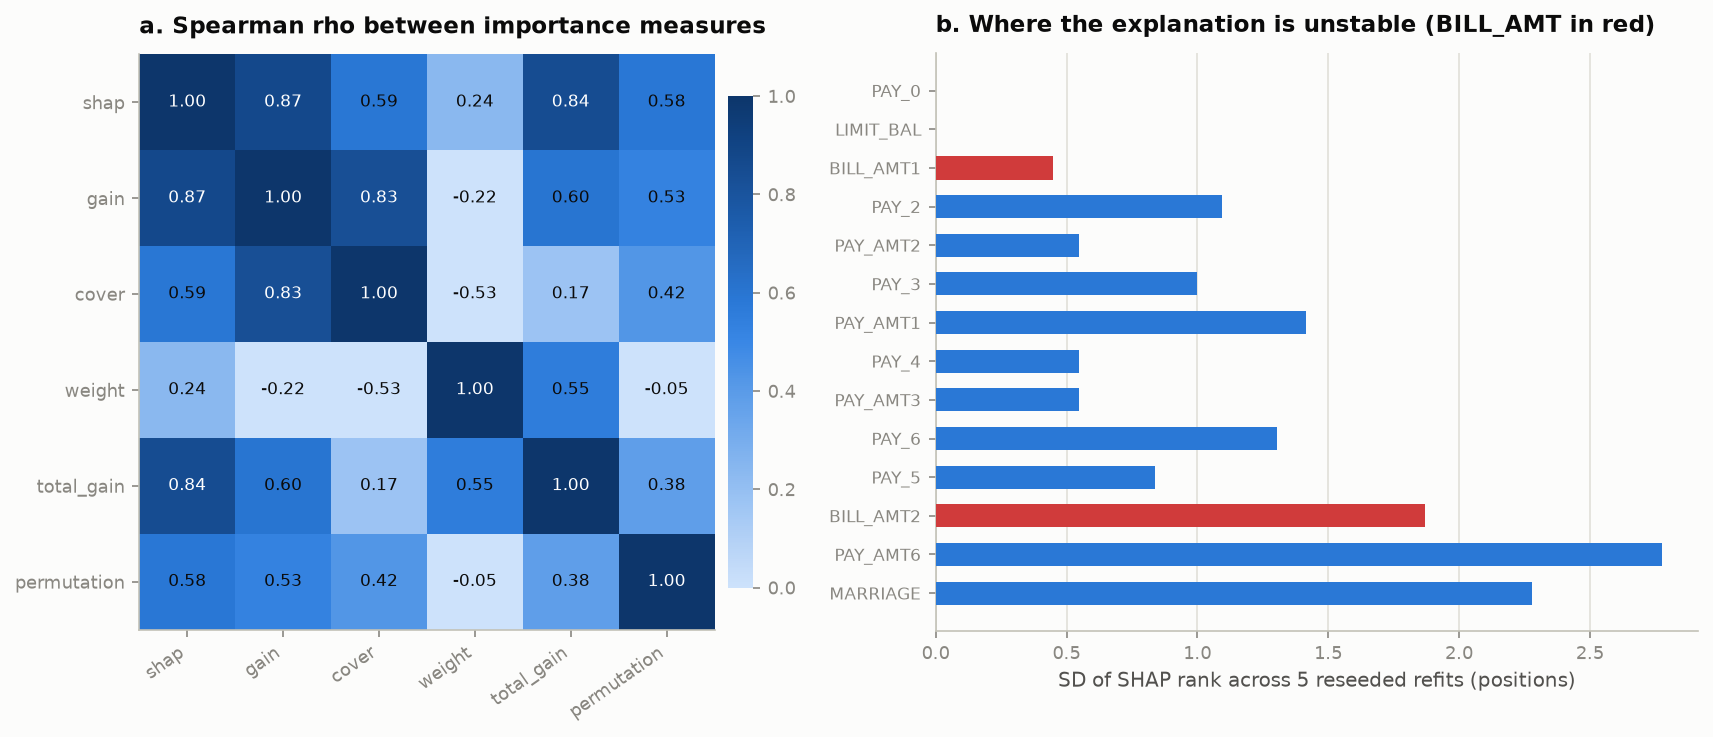

> Stability: across 5 reseeded refits, pairwise Spearman rho between mean|SHAP| vectors averages 0.9375 (minimum 0.8735) and the top-10 Jaccard index averages 0.8727 (minimum 0.8182). The global explanation is therefore reproducible at the level a regulator would ask about: the same features, in close to the same order, regardless of seed. Where instability does appear it is concentrated in the collinear block: mean rank SD is 1.73 positions for BILL_AMT1-6 against 1.16 for the remaining features. That is the VIF 13.9-25.7 collinearity of Phase 1 showing up as attribution instability rather than as a prediction problem -- which is exactly why the BILL_AMT columns are kept (trees are unharmed by collinearity) but read as a group when explained. Disagreement: the five importance measures rank features differently. Strongest agreement is shap|gain at rho 0.8725; weakest is cover|weight at rho -0.5257. `weight` counts how often a feature is split on, which rewards high-cardinality continuous columns regardless of whether the splits matter; `gain` is computed on training loss reduction and is not held-out. SHAP and permutation importance are preferred here because both are evaluated on held-out rows and both answer a question about predictions rather than about tree structure.

In [14]:
cfg = report.load("exp12_stability")["config"]
display(Markdown(
    f"Across {len(cfg['seeds'])} reseeded refits: mean pairwise Spearman "
    f"rho **{cfg['spearman_mean']:.4f}**, mean top-{cfg['top_k']} Jaccard "
    f"**{cfg['jaccard_mean']:.4f}**."))
fig("p2_app7_importance_agreement", 1000)
notes("exp12_stability")

---
## &sect;13 Fairness and subgroup analysis

Phase 1 &sect;2.2 quantified the demographic disparities already present in the data
precisely so that a later fairness check would be *interpretable rather than merely
alarming*. The question is therefore specific: does the model **amplify**, **preserve** or
**attenuate** a disparity that already exists?

Evaluated on out-of-fold training predictions rather than the test set. Nothing is
selected here &mdash; it is pure reporting &mdash; but out-of-fold keeps &sect;14's single
test-set gate intact and gives subgroup samples four times larger, so the Wilson intervals
are tighter.

Selection-rate ratios are read against the **four-fifths rule**, under which a ratio below
0.8 indicates disparate impact. Per-subgroup ROC-AUC is reported alongside the error rates
because equal ranking quality and equal error rates are different fairness criteria, and
no model satisfies both simultaneously unless the base rates are equal.

**Table 5 — subgroup summary, full model**

Attribute,Groups,Observed rate gap (pp),Recall gap,FPR gap,ROC-AUC gap,Selection-rate ratio,Four-fifths rule
SEX,2,3.44,0.0471,0.0833,0.0030,0.855,pass
EDUCATION,4,17.73,0.4505,0.2167,0.1974,0.535,FAIL
MARRIAGE,3,2.28,0.0235,0.1219,0.0737,0.841,pass
AGE_BAND,4,5.27,0.0580,0.1511,0.0230,0.773,FAIL


**Table 5b — subgroup summary, demographics removed**

Attribute,Groups,Observed rate gap (pp),Recall gap,FPR gap,ROC-AUC gap,Selection-rate ratio,Four-fifths rule
SEX,2,3.44,0.0237,0.0432,0.0053,0.914,pass
EDUCATION,4,17.73,0.2355,0.1240,0.1722,0.721,FAIL
MARRIAGE,3,2.28,0.0224,0.1582,0.0771,0.814,pass
AGE_BAND,4,5.27,0.0609,0.0940,0.0217,0.838,pass


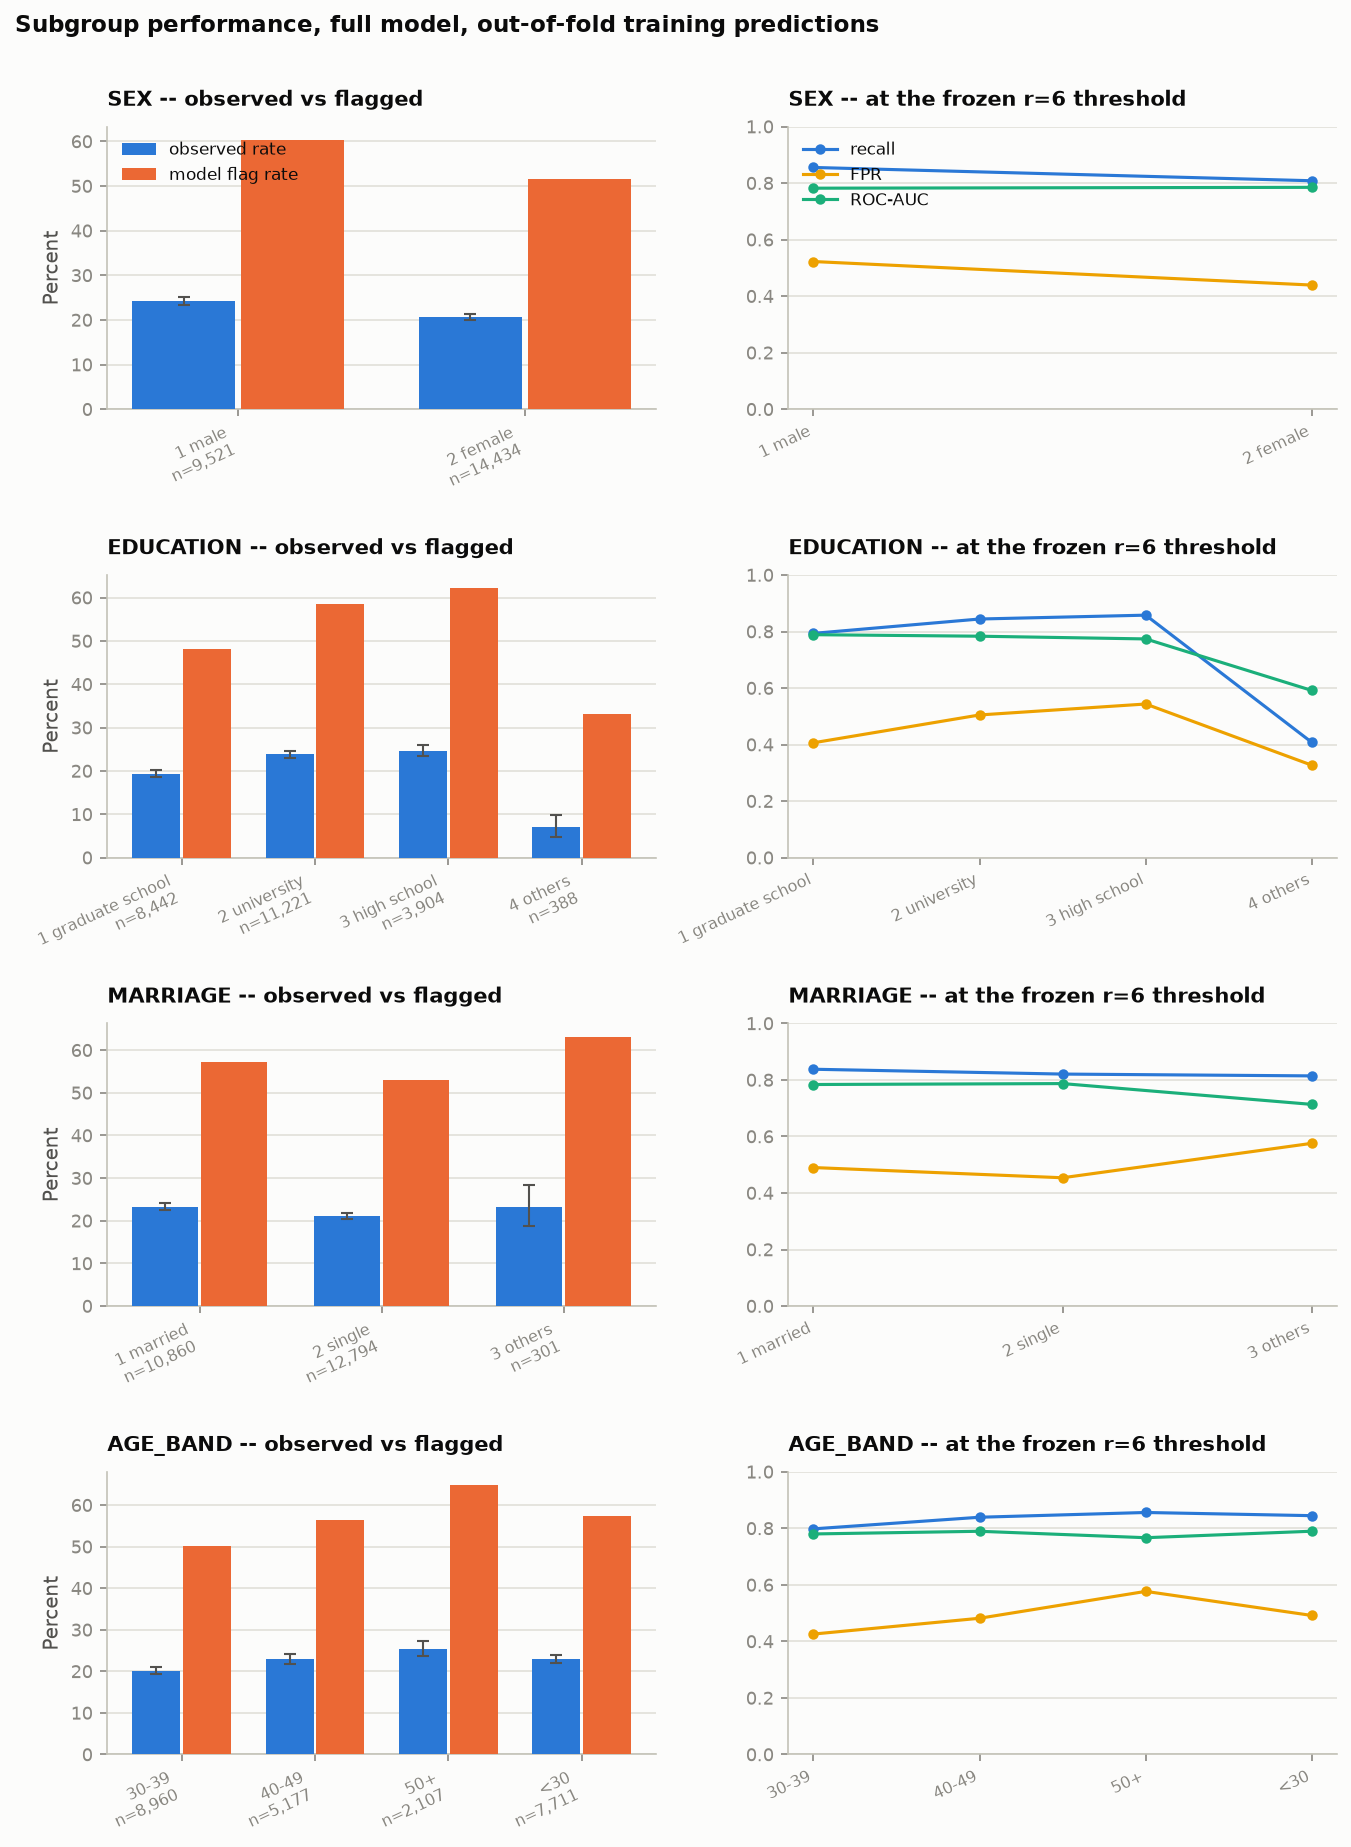

In [15]:
show(report.table5_fairness("full"), "Table 5 — subgroup summary, full model")
show(report.table5_fairness("no_demographics"),
     "Table 5b — subgroup summary, demographics removed")
fig("p2_app6_fairness", 1100)

In [16]:
show(report.table_fairness_detail("full"),
     "Table A8 — every subgroup with its Wilson 95% interval, full model")
notes("exp13_fairness")

**Table A8 — every subgroup with its Wilson 95% interval, full model**

Attribute,Group,n,Observed rate (%),Wilson 95% CI,ROC-AUC,PR-AUC,Recall,FPR,Flag rate
SEX,1 male,"9,521",24.19,"[23.34, 25.06]",0.7821,0.5719,0.8554,0.5226,0.6031
SEX,2 female,"14,434",20.75,"[20.10, 21.42]",0.7851,0.5523,0.8083,0.4393,0.5159
EDUCATION,1 graduate school,"8,442",19.38,"[18.55, 20.24]",0.7888,0.5393,0.7934,0.4063,0.4813
EDUCATION,2 university,"11,221",23.80,"[23.02, 24.60]",0.7834,0.5794,0.8443,0.5048,0.5856
EDUCATION,3 high school,"3,904",24.69,"[23.37, 26.07]",0.7738,0.5630,0.8579,0.5435,0.6212
EDUCATION,4 others,388,6.96,"[4.83, 9.94]",0.5914,0.1567,0.4074,0.3269,0.3325
MARRIAGE,1 married,"10,860",23.33,"[22.55, 24.14]",0.7838,0.5770,0.8378,0.4900,0.5712
MARRIAGE,2 single,"12,794",21.06,"[20.36, 21.77]",0.7871,0.5479,0.8207,0.4539,0.5311
MARRIAGE,3 others,301,23.26,"[18.84, 28.35]",0.7134,0.4800,0.8143,0.5758,0.6312
AGE_BAND,30-39,"8,960",20.12,"[19.31, 20.97]",0.7801,0.5254,0.7981,0.4259,0.5008


> Evaluated on out-of-fold training predictions at the frozen r=6 threshold (0.1341 for the full model). Nothing is selected here, and the test set is untouched; OOF also gives subgroup samples four times larger than the hold-out would, so the Wilson intervals are tighter. Observed disparity in the cleaned training rows: SEX default-rate gap 0.0344 and EDUCATION gap 0.1773, against Phase 1's reported male 24.16% versus female 20.77% and education 19.21% -> 23.74% -> 25.16%. The model's selection-rate gap is 0.0872 for SEX, a ratio of 2.536 against the observed gap -- so the model amplifies the disparity already in the data rather than creating one. For EDUCATION the ratio is 1.628. Per-subgroup ROC-AUC gaps are reported alongside, because equal ranking quality and equal error rates are different fairness criteria and this model does not satisfy both. Selection-rate ratios are given against the four-fifths rule threshold of 0.8. Proxy test: removing SEX, EDUCATION, MARRIAGE and AGE costs -0.00131 OOF ROC-AUC, yet the SEX selection-rate gap only falls from 0.0872 to 0.0506 -- 58.0% of it survives. The financial columns proxy for the demographics, so dropping the protected columns hides the influence rather than removing it, exactly as Barocas & Selbst (2016) predict. Fairness-through-unawareness is not available on this dataset.

---
## &sect;14 Robustness and the held-out evaluation

The single test-set gate. Every threshold below was frozen on out-of-fold *training*
predictions before this table was computed, and no hyperparameter or operating point is
selected here.

Three robustness checks run alongside it:

1. **The `PAY_0` construction anomaly.** Phase 1 recorded repayment code `1` appearing 0,
   0, 2, 4 and 28 times from April to August, then **3,688** times in September. That
   suggests `PAY_0` is constructed differently from the five historical columns &mdash; and
   it is the most predictive variable in the dataset. Reporting the delta is worth more
   than hiding it.
2. **Seed variance** over 10 refits, which sets the floor below which no difference in
   this report should be called a win.
3. **DeLong's test**, tuned XGBoost against the `PAY_0` single-rule baseline. Paired,
   correlated ROC curves on one sample is exactly DeLong's remit; it is never applied
   across CV folds here, where the samples are not independent.

**Table 6 — held-out evaluation at the frozen thresholds**

Configuration,Features,Frozen tau,ROC-AUC,PR-AUC,Brier,Recall,Precision,F1,TP/FP/FN/TN,Cost (r=6)
rung1_pay0_baseline,1,0.0001,0.64299,0.37629,0.14607,1.0000,0.2211,0.3621,1324/4665/0/0,"4,665"
rung5_xgb_default,23,0.0881,0.76068,0.52700,0.14078,0.8557,0.2963,0.4402,1133/2691/191/1974,"3,837"
xgb_tuned,23,0.1341,0.78293,0.56382,0.13345,0.8444,0.3261,0.4705,1118/2310/206/2355,"3,546"
xgb_tuned_no_pay0,22,0.1381,0.75185,0.50575,0.14252,0.8437,0.3033,0.4462,1117/2566/207/2099,"3,808"
xgb_tuned_no_demographics,19,0.1341,0.78065,0.56141,0.13395,0.8414,0.3222,0.4659,1114/2344/210/2321,"3,604"
xgb_tuned_spw,23,0.3580,0.78288,0.56224,0.17974,0.8346,0.3347,0.4778,1105/2196/219/2469,"3,510"
xgb_tuned_isotonic,23,0.1401,0.78095,0.54691,0.13441,0.7258,0.3846,0.5027,961/1538/363/3127,"3,716"


**Table 6b — DeLong tests on the held-out set**

Comparison,AUC A,AUC B,Difference,95% CI,p
tuned vs pay0 rule,0.78293,0.64299,+0.13994,"[+0.12678, +0.15309]",1.48e-96
tuned vs no pay0,0.78293,0.75185,+0.03108,"[+0.02326, +0.03890]",6.6e-15
tuned vs library defaults,0.78293,0.76068,+0.02225,"[+0.01450, +0.02999]",1.79e-08


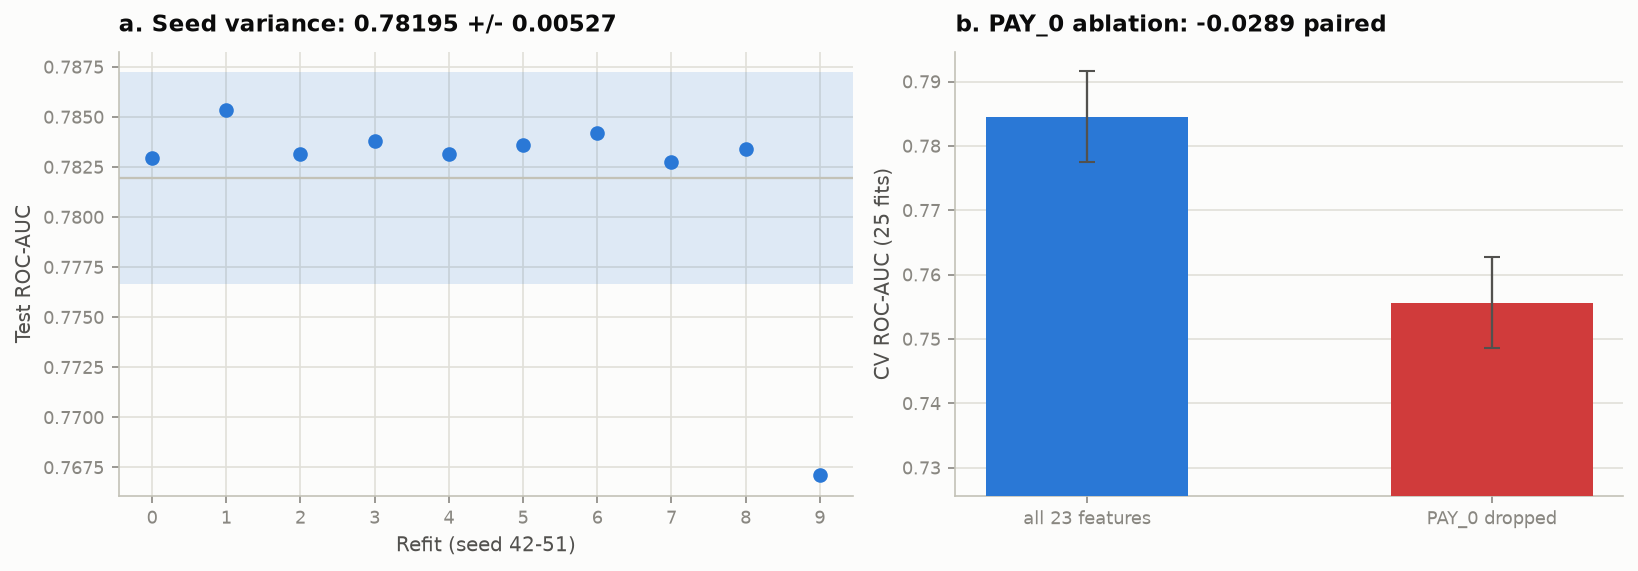

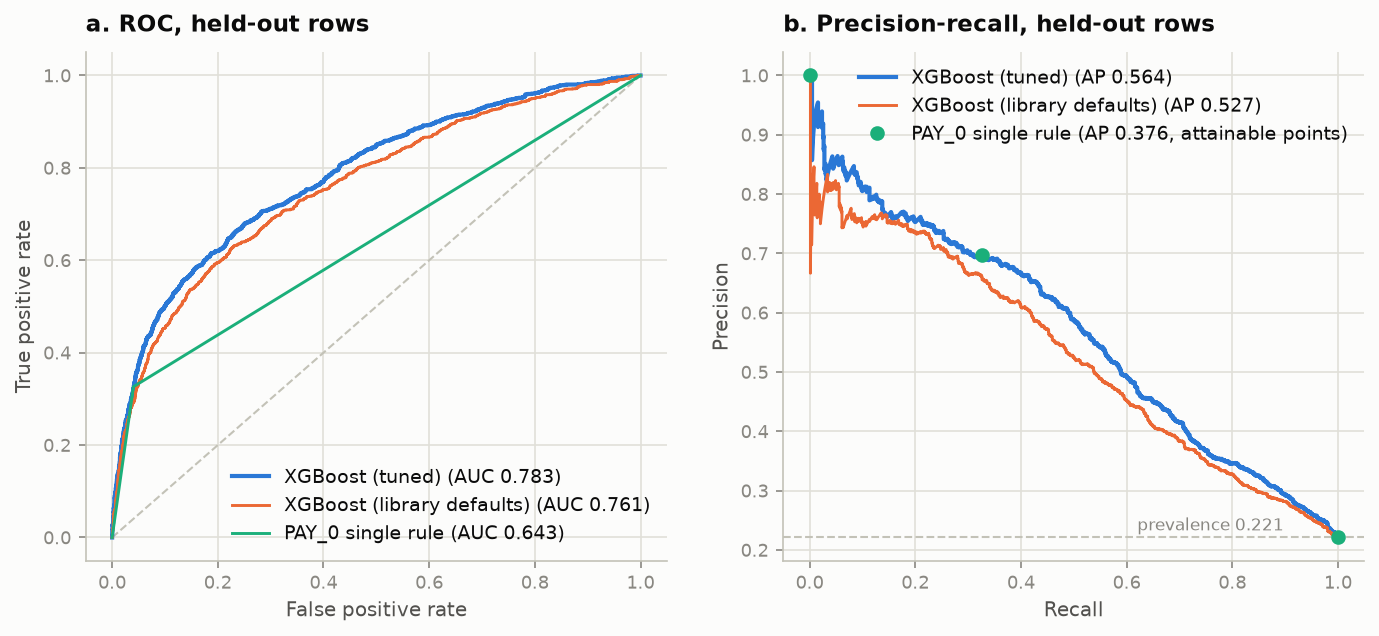

> Single test-set gate. 5,989 held-out rows, 1,324 positives; every threshold was frozen on out-of-fold training predictions at r=6 before this file read the hold-out, and no hyperparameter or operating point is selected here. Headline: test ROC-AUC 0.78293, PR-AUC 0.56382, Brier 0.13345, and at the frozen threshold 0.1341 recall 0.8444 against precision 0.3261 (1118 TP, 2310 FP, 206 FN, 2355 TN). Against the PAY_0 single-rule baseline the DeLong difference is +0.13994 (95% CI +0.12678 to +0.15309, p=1.48e-96), so the ensemble's advantage over one rule is real and not a fold artefact. Against untuned XGBoost the difference is +0.02225 (p=1.79e-08) -- tuning buys far less than capability does, which is itself the answer to how much of the ladder's climb is architecture rather than search. PAY_0 anomaly: Phase 1 recorded repayment code 1 appearing 0, 0, 2, 4, 28 times April-August and 3,688 times in September, so PAY_0 looks constructed differently from the five historical columns. Dropping it costs -0.02888 CV ROC-AUC across the 25 repeated fits (paired per-fold, p=8.11e-21; Nadeau & Bengio (2003) note such tests are anti-conservative because the training folds overlap, so read the effect size, not the p-value) and -0.03108 on the test set. The headline therefore leans on a column with a documented irregularity, and that is reported rather than hidden: the model without PAY_0 still reaches 0.75185, so the result is not an artefact of the anomaly, but a production deployment should verify how the most recent repayment status is derived. Seed variance: 10 refits of the final configuration give test ROC-AUC 0.78195 +/- 0.00527 (range 0.01826). Any comparison closer than roughly 0.0105 is not distinguishable from reseeding noise, and the report does not bold one. Irreducible floor: 0 groups of feature-identical clients carry contradictory labels, covering 0 rows, 0.0% of the 29,944 cleaned rows. That contribution is small, so the honest claim is not that label noise explains the error. It is that AUC 1.0 is formally unattainable once contradictory rows exist at all, and more importantly that the feature set is a six-month billing snapshot which cannot observe job loss, illness or an income shock. Plateauing near ROC-AUC 0.78 is a feature-set ceiling, not a model deficiency -- supported by the learning curve of WP12 flattening well before the full training set and by the small tuned-versus-untuned gap measured above.

In [17]:
show(report.table_test(), "Table 6 — held-out evaluation at the frozen thresholds")

cfg = report.load("exp14_final")["config"]
dl = cfg["delong"]
rows = [(k.replace("_", " "), f"{v['auc_a']:.5f}", f"{v['auc_b']:.5f}",
         f"{v['diff']:+.5f}", f"[{v['ci95'][0]:+.5f}, {v['ci95'][1]:+.5f}]",
         f"{v['p_value']:.3g}") for k, v in dl.items()]
show(pd.DataFrame(rows, columns=["Comparison", "AUC A", "AUC B", "Difference",
                                 "95% CI", "p"]),
     "Table 6b — DeLong tests on the held-out set")
fig("p2_app9_robustness", 1000)
fig("p2_fig2_roc_pr", 1000)
notes("exp14_final")

---
## &sect;15 Phase 2 findings

The reproduction record: every experiment, its runtime, and when it was run. If two
`run_utc` values straddle a change to `src/`, the results are not comparable and the chain
must be re-run.

In [18]:
rt = report.runtimes()
show(rt, "Table 7 — reproduction record")
display(Markdown(f"**Total compute: {rt['Runtime (s)'].sum() / 60:.1f} minutes across "
                 f"{len(rt)} experiments.**"))

manifest = pd.read_csv("results/manifest.csv")
display(Markdown(f"`results/manifest.csv`: **{len(manifest)} rows**, "
                 f"{manifest.shape[1]} columns. Every number in the report traces here."))

**Table 7 — reproduction record**

Experiment,Title,Rows,Runtime (s),Run (UTC)
exp01_ladder,Complexity ladder: capability against interpretability,8,104.900000,2026-09-30T09:15:03Z
exp02_tuning,Hyperparameter search (Optuna TPE),2,1166.300000,2026-09-30T08:58:21Z
exp03_imbalance,Class-imbalance strategy comparison,5,302.000000,2026-09-30T09:47:34Z
exp04_encoding,Encoding ablation for repayment-status columns,4,186.100000,2026-09-30T09:03:53Z
exp05_engineered,Engineered-feature benchmark,4,165.700000,2026-09-30T09:06:41Z
exp06_groups,Feature-group ablation,11,297.700000,2026-09-30T09:11:42Z
exp07_recency,Recency ablation: months of history required,6,235.800000,2026-09-30T09:15:40Z
exp08_learning_curve,Learning curve against training-set size,5,120.700000,2026-09-30T09:17:44Z
exp09_calibration,"Calibration: Brier, ECE and reliability curves",6,16.000000,2026-09-30T09:47:53Z
exp10_cost,Cost-sensitive threshold selection with Elkan overlay,18,0.900000,2026-09-30T09:47:56Z


**Total compute: 47.6 minutes across 14 experiments.**

`results/manifest.csv`: **130 rows**, 102 columns. Every number in the report traces here.

### What the two research questions ended up being answered with

**Q1 &mdash; is the ensemble's gain worth the interpretability loss?** &sect;7 prices it.
The honest answer is conditional, not a yes: the climb from one rule to a tuned ensemble
is real and survives DeLong's test on held-out data, but most of it is bought by the
*first* step into non-linearity rather than by boosting or by tuning &mdash; and it is paid
for with an interpretability cost three orders of magnitude larger. For a lender that must
issue adverse-action notices, that trade is only defensible if something replaces the lost
rule set, which is what Q2 asks.

**Q2 &mdash; can post-hoc explanation bridge the gap?** &sect;12 says *partly, and with
conditions*. The global explanation is stable under reseeding at the level a regulator
would ask about, and it independently recovers a data pattern nobody encoded, which is
real evidence of fidelity. But the five importance measures disagree, individual
`BILL_AMT` attributions are unstable under the Phase 1 collinearity, and SHAP attributes
the model's output rather than a causal mechanism. It answers *why did this model decide
that*, which is the auditability question, and not *what would happen if we changed this*,
which is what a declined applicant actually wants to know.

The narrative discussion of what worked, what did not, and what was surprising is in the
report's Summary section rather than duplicated here.